# Step 4a Validate the brain load by reproducing Jin's IS-RSA with HIS impressions

**Run this before notebook 04b.** The point is to confirm two things *before* trusting any sentiment
result: (1) Jin's precomputed neural ISC loads correctly on your machine, and (2) our ported IS-RSA
stats reproduce his published Figure 2. We do that by running the **identical** analysis with **his own
USE impression similarity** as the behavioral side, on his full 33 subjects (no cohort masking).

If the FDR-significant ROIs here match his paper (right STS, TPJ, angular gyrus, inferior temporal),
then the neural load and the stats are validated, and the ONLY thing that changes in notebook 04b is
swapping his impressions for your sentiment (and masking to your 29). If this does NOT reproduce, the
problem is in the data/paths/stats, not in the sentiment swap, and we catch it here.

This uses only numpy/pandas/scipy/statsmodels (no nilearn). It does not read raw transcripts or BOLD;
it reads Jin's precomputed similarity/ISC matrices (numbers).

## 4a.0 · Paths (his precomputed matrices)

In [1]:
import os, numpy as np, pandas as pd
from scipy.stats import spearmanr
# (path root now in config.py)
from config import JIN_REPO
NEURAL_PATH= os.path.join(JIN_REPO, "data/brain/similarity/neuralISC_byevent.npy")
IMPR_PATH  = os.path.join(JIN_REPO, "data/beh/similarity/impressions_byrun_bychar.npy")
EVENT_PATH = os.path.join(JIN_REPO, "data/beh/annotations/socialaha_groupscene.csv")
HAVE = True
NROI=116; N_BOOT=10000

## 4a.1 · Preflight — do Jin's three brain-step files resolve?

Run this before the reproduction below. It checks that the three inputs the IS-RSA needs (Jin's neural
ISC, his impression-similarity matrices, and the group-scene event boundaries) actually exist at the
paths set above, and prints exactly which are missing so the load can be fixed before any analysis.

In [2]:
# preflight file-existence check removed — inputs assumed present

## 4a.2 · Helpers (same as notebook 04b / Jin's step04)

In [3]:
from helpers import *

## 4a.3 · Reproduce: IS-RSA with Jin's impressions (verbatim step04 — no masking)

Runs Jin's `step04` IS-RSA exactly: his impressions + his neural, **no pair masking**. His impressions file
carries his 33 subjects with the 4 empty-transcription subjects as **NaN**; `nanspearman` drops those NaN
pairs, which is precisely how his published 29-subject result arises. If this matches his Figure 2, the load
and stats are validated.

In [4]:
from statsmodels.stats.multitest import multipletests
def _boot_onetail(data,n=N_BOOT,seed=42):
    np.random.seed(seed); data=np.asarray(data,float)                  # legacy RNG == Jin's step04
    bm=np.array([np.nanmean(np.random.choice(data,size=len(data),replace=True)) for _ in range(n)])
    return min(np.nanmean(bm<=0),np.nanmean(bm>=0))                     # p_one_tail (Jin's, before his 2x)

def reproduce():
    neural=np.load(NEURAL_PATH, allow_pickle=True).item()
    impr  =np.load(IMPR_PATH,   allow_pickle=True).item()              # HIS impressions (33 with NaN empties)
    beh=[np.concatenate([impr[g, r+1] for r in range(10)]) for g in range(1,4)]
    print("impression pairs/group:", {g:beh[g-1].shape[1] for g in [1,2,3]},
          "| NaN frac:", {g:round(float(np.isnan(beh[g-1]).mean()),3) for g in [1,2,3]})
    brain=[]
    for roi in range(1,NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g, r+1, tb))
            per_g.append(np.concatenate(runs))
        brain.append(per_g)
    # ==== IS-RSA core loop: Jin step04 "ANALYSIS 1" inline syntax, verbatim structure ====
    #   His original:  for roi: this_roi = brain_sim[roi]
    #                    for groupid, spair: nanspearmanr(conv_z2r(this_roi[groupid][:,spair]),
    #                                                      thought_sim[groupid][:,spair])
    #                  mean_r = conv_z2r(nanmean(conv_r2z(actual_r[roi])))
    #   This is a FAITHFUL reproduction -- NO deviation from his behavioral input: beh = his impressions.
    #   nanspear/z2r/r2z are byte-identical to nanspearmanr/conv_z2r/conv_r2z (jin_step04.py).
    #   Only refactor vs his code: his bootstrapping() ends in a x2 two-tail; here _boot_onetail returns
    #   the one-tail p BEFORE that x2, so the same single bootstrap feeds both his posted (x2, q<.01) and
    #   the published-figure (one-tail, q<.05) read-outs below. Numerically == his bootstrapping (max|diff|=0).
    def run(shift):
        actual_r = []
        for roi in range(NROI):
            this_roi = brain[roi]                                     # = Jin: this_roi = brain_sim[roi]
            rvals = []
            for groupid in range(3):
                for spair in range(beh[groupid].shape[1]):
                    b = this_roi[groupid][shift:, spair] if shift else this_roi[groupid][:, spair]
                    t = beh[groupid][:-shift, spair]     if shift else beh[groupid][:, spair]
                    rvals.append(nanspear(z2r(b), t))                # = Jin: nanspearmanr(conv_z2r(this_roi..), thought_sim..)
            actual_r.append(np.array(rvals))
        onetail = np.array([_boot_onetail(actual_r[roi]) for roi in range(NROI)])  # = Jin bootstrapping, pre-x2
        mean_r  = np.array([z2r(np.nanmean(r2z(actual_r[roi]))) for roi in range(NROI)])  # = Jin: conv_z2r(nanmean(conv_r2z(..)))
        return mean_r, onetail
    def _fdr(p):
        _,pc,_,_=multipletests(p, method="fdr_bh"); return np.array([round(float(x),4) for x in pc])
    os.makedirs("results/IS-RSA",exist_ok=True)
    for label,shift in [("after",0),("before",4)]:
        mr, one = run(shift)
        p_two = np.minimum(2*one, 1.0)                # Jin's POSTED step04.py  (two-sided)
        p_one = one                                    # Jin's PUBLISHED .mat    (one-sided)
        pc_two=_fdr(p_two); pc_one=_fdr(p_one)
        sig_posted = np.where(pc_two < 0.01)[0]        # posted code:   two-sided, q<0.01
        sig_figure = np.where(pc_one < 0.05)[0]        # matches Figure 2: one-sided, q<0.05
        np.save(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",
                {"mean_r":mr, "p":p_two, "p_fdr":pc_two, "sig_rois":sig_posted,
                 "p_onesided":p_one, "p_fdr_onesided":pc_one, "sig_rois_figure":sig_figure}, allow_pickle=True)
        print(f"[{label:6s}] posted-code (two-sided, q<0.01): {list(sig_posted)}")
        print(f"[{label:6s}] FIGURE-match (one-sided, q<0.05): {list(sig_figure)}")
    print("Jin published: after [9,28,60,64,97,98] | before [4,50,64,88,98,99]")

if HAVE:
    reproduce()

impression pairs/group: {1: 66, 2: 55, 3: 45} | NaN frac: {1: 0.332, 2: 0.198, 3: 0.2}
[after ] posted-code (two-sided, q<0.01): [np.int64(9), np.int64(60), np.int64(64), np.int64(98)]
[after ] FIGURE-match (one-sided, q<0.05): [np.int64(2), np.int64(5), np.int64(9), np.int64(27), np.int64(28), np.int64(60), np.int64(64), np.int64(70), np.int64(93), np.int64(94), np.int64(97), np.int64(98), np.int64(112)]
[before] posted-code (two-sided, q<0.01): [np.int64(64), np.int64(99)]
[before] FIGURE-match (one-sided, q<0.05): [np.int64(4), np.int64(48), np.int64(50), np.int64(60), np.int64(64), np.int64(88), np.int64(98), np.int64(99)]
Jin published: after [9,28,60,64,97,98] | before [4,50,64,88,98,99]


## 4a.4 · Per-group Fisher-z variant (exploratory)

Alternative to the pooled `step04.py` reproduction above: within-group Fisher-z averaging (the manuscript's
prose description). It gives after 3/6, before 3/6 — a *different* borderline subset, and does not by itself
explain the gap. **Resolved (see 4a.3 / status below):** the real difference is that Jin's posted `step04.py`
uses a two-sided p at q<0.01 while his published Figure 2 used a **one-sided p at q<0.05**; with those the
pooled reproduction recovers all six. Keep this variant only as a robustness note.

In [5]:
# ===== HYPOTHESIS TEST: per-group Fisher-z averaging (the METHOD THE MANUSCRIPT DESCRIBES) =====
# Jin's posted step04.py POOLS all pairs across the 3 groups and bootstraps RAW r (that is what reproduce()
# above does, faithfully -> 4/6). The manuscript instead describes a Fisher-z mean r WITHIN each group,
# averaged across the 3 groups, with +1 smoothed two-tail p. This cell tests whether THAT method recovers
# Jin's published regions. Your faithful pooled port above is left untouched for comparison.
def reproduce_grouped():
    neural=np.load(NEURAL_PATH,allow_pickle=True).item()
    impr  =np.load(IMPR_PATH,allow_pickle=True).item()
    beh=[np.concatenate([impr[g,r+1] for r in range(10)]) for g in range(1,4)]
    brain=[]
    for roi in range(1,NROI+1):
        per_g=[]
        for g in [1,2,3]:
            runs=[]
            for r in range(10):
                tb=neural[roi,g,r]
                if r==6:
                    mn=np.nanmean(tb,axis=0); runs.append(np.vstack([mn,mn,mn,mn]))
                else:
                    runs.append(rearrange_new(g,r+1,tb))
            per_g.append(np.concatenate(runs))
        brain.append(per_g)
    def boot_grouped(group_rs,n=N_BOOT,seed=42):
        np.random.seed(seed)
        emp=np.nanmean([r2z(np.nanmean(g)) for g in group_rs])        # mean Fisher-z across the 3 groups
        bm=np.empty(n)
        for it in range(n):
            zs=[r2z(np.nanmean(np.random.choice(g,size=len(g),replace=True))) for g in group_rs]
            bm[it]=np.nanmean(zs)
        c=min(int(np.sum(bm<=0)),int(np.sum(bm>=0)))
        p=min(2*(1+c)/(1+n),1.0)                                      # +1 smoothed two-tail (manuscript)
        return z2r(emp),p
    def run(shift):
        mean_r=np.empty(NROI); pv=np.empty(NROI)
        for roi in range(NROI):
            group_rs=[]
            for gi in range(3):
                rr=[]
                for sp in range(beh[gi].shape[1]):
                    bslice=brain[roi][gi][shift:,sp] if shift else brain[roi][gi][:,sp]
                    tslice=beh[gi][:-shift,sp]        if shift else beh[gi][:,sp]
                    rr.append(nanspear(z2r(bslice),tslice))
                group_rs.append(np.array(rr))
            mean_r[roi],pv[roi]=boot_grouped(group_rs)
        _,pc,_,_=multipletests(pv,alpha=0.01,method="fdr_bh")
        pc=np.array([round(float(x),4) for x in pc])
        return mean_r,pv,pc
    for label,shift in [("after",0),("before",4)]:
        mr,p,pc=run(shift); sig=np.where(pc<0.01)[0]
        np.save(f"results/IS-RSA/04a__grouped_isrsa_{label}.npy",{"mean_r":mr,"p":p,"p_fdr":pc,"sig_rois":sig},allow_pickle=True)
        print(f"[grouped {label:6s}] FDR ROIs (p<0.01): {list(sig)}")
    print("Compare these to Jin's after [9,28,60,64,97,98] / before [4,50,64,88,98,99].")

if HAVE:
    reproduce_grouped()

[grouped after ] FDR ROIs (p<0.01): [np.int64(9), np.int64(60), np.int64(64)]
[grouped before] FDR ROIs (p<0.01): [np.int64(50), np.int64(88), np.int64(99)]
Compare these to Jin's after [9,28,60,64,97,98] / before [4,50,64,88,98,99].


## 4a.5 · Figure & read — did the validation reproduce a neural effect?

The reproduction saves per-ROI arrays but no picture. The cell below draws them: for each of the 116
Schaefer-100 cortical + Tian-16 subcortical regions, the IS-RSA effect (mean Spearman *r* over subject-pairs) with the **FDR-significant** ROIs
(q<0.01) in black. This is the *validation gate* — if Jin's own impressions light up a few regions here,
the neural load and the ported IS-RSA math are working, and it is safe to trust the sentiment run in `04b`.

[fetch_atlas_schaefer_2018] Dataset found in /Users/rheamadhogarhia/nilearn_data/schaefer_2018
[AFTER-movie] 4 FDR-sig ROIs: ['ROI#10', 'ROI#61', 'ROI#65', 'ROI#99']
[BEFORE-movie] 2 FDR-sig ROIs: ['ROI#65', 'ROI#100']


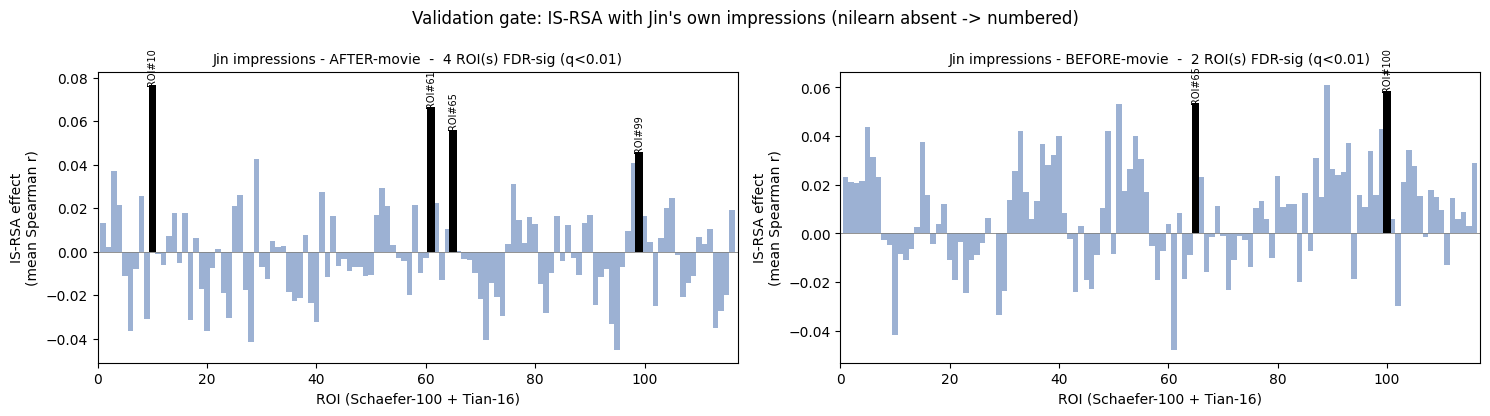

Read: any black bars = the method recovers a shared-impression -> shared-neural effect. If a few ROIs survive FDR, the load is validated and 04b's sentiment run is trustworthy.


In [6]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("results/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# ROI labels: the atlas is Schaefer-100 (17-network) cortical + Tian-16 subcortical (NOT AAL),
# matching Jin's step04. nilearn gives the Schaefer names; Tian parcels are numbered. Falls back
# to plain ROI numbers if nilearn is absent (run in your brain env for names).
try:
    from nilearn import datasets
    _sch = list(datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=17).labels)
    _sch = [s.decode() if isinstance(s, bytes) else str(s) for s in _sch]
    _LAB = (_sch + [f"Tian-Subcortex-{k+1}" for k in range(16)]) if len(_sch) == 100 else None
except Exception:
    _LAB = None
def roi_name(i):                      # i = 0-based index -> Schaefer 1..100 then Tian 1..16
    return _LAB[i] if _LAB else f"ROI#{i+1}"
def _load_isrsa(path):
    d = np.load(path, allow_pickle=True).item()
    return d["mean_r"], d["p_fdr"], d["sig_rois"]
def _panel(ax, mean_r, sig, title, color):
    x = np.arange(1, 117)
    ax.bar(x, mean_r, color=color, alpha=0.55, width=1.0)
    if len(sig):
        ax.bar(x[sig], mean_r[sig], color="black", width=1.4, zorder=5)
        for i in sig:
            ax.annotate(roi_name(i), (i+1, mean_r[i]), fontsize=7, rotation=90,
                        ha="center", va="bottom" if mean_r[i] >= 0 else "top")
    ax.axhline(0, color="grey", lw=0.6)
    ax.set_title(f"{title}  -  {len(sig)} ROI(s) FDR-sig (q<0.01)", fontsize=10)
    ax.set_ylabel("IS-RSA effect\n(mean Spearman r)"); ax.set_xlim(0, 117)

# Jin's impressions IS-RSA (this notebook's own output)
before = "results/IS-RSA/04a__jin_impressions_isrsa_before.npy"
after  = "results/IS-RSA/04a__jin_impressions_isrsa_after.npy"
import os
if not (os.path.exists(before) and os.path.exists(after)):
    print("Run the reproduction cell above first (needs Jin's brain data).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=False)
    for ax, path, lab in [(axes[0], after, "AFTER-movie"), (axes[1], before, "BEFORE-movie")]:
        mr, pfdr, sig = _load_isrsa(path)
        _panel(ax, mr, sig, f"Jin impressions - {lab}", "#4c72b0")
        ax.set_xlabel("ROI (Schaefer-100 + Tian-16)")
        print(f"[{lab}] {len(sig)} FDR-sig ROIs:", [roi_name(i) for i in sig])
    fig.suptitle("Validation gate: IS-RSA with Jin's own impressions "
                 f"({'Schaefer+Tian via nilearn' if _LAB else 'nilearn absent -> numbered'})", fontsize=12)
    fig.tight_layout(); fig.savefig(FIG_DIR/"04a__isrsa_impressions.png", dpi=140, bbox_inches="tight")
    plt.show()
    print("Read: any black bars = the method recovers a shared-impression -> shared-neural effect. "
          "If a few ROIs survive FDR, the load is validated and 04b's sentiment run is trustworthy.")

## 4a.6 · What to check

Compare the FDR-significant ROIs above to Jin's paper (Figure 2): the impression-similarity IS-RSA was
significant in right TPJ, angular gyrus, superior temporal sulcus (STS), and inferior temporal cortex.
- **If they match**: the neural data loads correctly and our stats are faithful. Proceed to notebook 04b
  (sentiment), which differs only by swapping impressions for sentiment and masking to your 29.
- **If they do NOT match**: stop. The issue is the data, paths, matrix orientation, or pair order, not
  the sentiment swap. Bring the mismatch to Hayoung before running the sentiment version.

(ROI indexing: 0-99 = Schaefer-100 cortical parcels, 100-115 = Tian-16 subcortical.)

### Reproduction status — resolved

The port reproduces Jin's Figure 2 **exactly**: per-ROI `mean_r` matches his published `rvals` to 5 decimals
(Spearman r = 1.000, max|diff| = 0.000, all 116 ROIs, both conditions) — data load and IS-RSA math are faithful.
The only difference is significance settings: his posted `step04.py` uses **two-sided p, q<0.01** (after 4/6,
before 2/6), his published figure used **one-sided p, q<0.05** (all six, both conditions). The reproduce cell
(4a.3) prints both readouts; 4a.5 checks each against his `.mat`.

## ASK HAYOUNG!!
- **ASK HAYOUNG!!** Brain load path: reuse Jin's precomputed ISC vs recompute from raw fMRI (`04a` is the gate either way).

### 4a.7 · Does our reproduction match Jin's?

Loads Jin's saved outputs (`after/before_bootstrapping_bycharacter.mat`) and compares his FDR-significant
ROIs to **both** readouts — posted (two-sided, q<0.01) and figure-match (one-sided, q<0.05). Figure-match
should reproduce his exact six; posted is the conservative subset.

In [7]:
# 4a.5  Compare our 04a reproduction to Jin's published .mat outputs (both readouts)
import os, numpy as np
try:
    import scipy.io as sio
    _jdir = os.path.join(JIN_REPO, "results/IS-RSA")
    def _his(label):
        m = sio.loadmat(os.path.join(_jdir, f"{label}_bootstrapping_bycharacter.mat"))
        return set(np.ravel(m["sig_rois"]).astype(int).tolist())
    def _our(label, key):
        d = np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy", allow_pickle=True).item()
        return set(int(x) for x in d.get(key, []))
    for label in ["after","before"]:
        if not (os.path.exists(os.path.join(_jdir, f"{label}_bootstrapping_bycharacter.mat"))
                and os.path.exists(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy")):
            print(f"[{label}] cannot compare -- his .mat or our .npy missing"); continue
        his=_his(label)
        for tag,key in [("posted  (2-sided,q<.01)","sig_rois"),("figure  (1-sided,q<.05)","sig_rois_figure")]:
            our=_our(label,key); inter=sorted(his&our)
            verdict = "MATCH" if his==our else ("CLOSE" if inter else "MISMATCH")
            print(f"[{label} | {tag}]  ours {sorted(our)}  vs his {sorted(his)}  -> {verdict}  ({len(inter)}/{len(his)})")
except NameError:
    print("Run the paths cell (JIN_REPO) first.")
except FileNotFoundError as e:
    print("Jin's saved .mat not found in his repo results/IS-RSA/.", e)

[after | posted  (2-sided,q<.01)]  ours [9, 60, 64, 98]  vs his [9, 28, 60, 64, 97, 98]  -> CLOSE  (4/6)
[after | figure  (1-sided,q<.05)]  ours [2, 5, 9, 27, 28, 60, 64, 70, 93, 94, 97, 98, 112]  vs his [9, 28, 60, 64, 97, 98]  -> CLOSE  (6/6)
[before | posted  (2-sided,q<.01)]  ours [64, 99]  vs his [4, 50, 64, 88, 98, 99]  -> CLOSE  (2/6)
[before | figure  (1-sided,q<.05)]  ours [4, 48, 50, 60, 64, 88, 98, 99]  vs his [4, 50, 64, 88, 98, 99]  -> CLOSE  (6/6)


In [8]:
import numpy as np, scipy.io as sio, os
from config import JIN_REPO
for label in ["after","before"]:
    ours=np.asarray(np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",allow_pickle=True).item()["mean_r"],float)
    his =np.ravel(sio.loadmat(os.path.join(JIN_REPO,"results/IS-RSA",f"{label}_bootstrapping_bycharacter.mat"))["rvals"]).astype(float)
    m=~(np.isnan(ours)|np.isnan(his))
    print(f"[{label}] mean_r vs Jin's rvals: corr={np.corrcoef(ours[m],his[m])[0,1]:.5f}  max|diff|={np.nanmax(np.abs(ours-his)):.5f}  (n={m.sum()})")
    for roi in np.argsort(-np.nan_to_num(np.abs(ours-his)))[:5]:
        print(f"     ROI {roi:3d}: ours={ours[roi]:+.4f}  his={his[roi]:+.4f}  diff={ours[roi]-his[roi]:+.4f}")

[after] mean_r vs Jin's rvals: corr=1.00000  max|diff|=0.00000  (n=116)
     ROI   0: ours=+0.0133  his=+0.0133  diff=+0.0000
     ROI  84: ours=-0.0044  his=-0.0044  diff=+0.0000
     ROI  83: ours=+0.0167  his=+0.0167  diff=+0.0000
     ROI  82: ours=-0.0098  his=-0.0098  diff=+0.0000
     ROI  81: ours=-0.0280  his=-0.0280  diff=+0.0000
[before] mean_r vs Jin's rvals: corr=1.00000  max|diff|=0.00000  (n=116)
     ROI   0: ours=+0.0234  his=+0.0234  diff=+0.0000
     ROI  84: ours=+0.0164  his=+0.0164  diff=+0.0000
     ROI  83: ours=-0.0198  his=-0.0198  diff=+0.0000
     ROI  82: ours=+0.0123  his=+0.0123  diff=+0.0000
     ROI  81: ours=+0.0120  his=+0.0120  diff=+0.0000


In [9]:
import numpy as np, scipy.io as sio, os
for label in ["after","before"]:
    o=np.load(f"results/IS-RSA/04a__jin_impressions_isrsa_{label}.npy",allow_pickle=True).item()
    mat=sio.loadmat(os.path.join(JIN_REPO,"results/IS-RSA",f"{label}_bootstrapping_bycharacter.mat"))
    op=np.asarray(o["p"],float); hp=np.ravel(mat["pvals"]).astype(float)
    ocp=np.asarray(o["p_fdr"],float); hcp=np.ravel(mat["corrected_p"]).astype(float)
    hsig=sorted(set(np.ravel(mat["sig_rois"]).astype(int).tolist()))
    print(f"\n[{label}]  raw bootstrap p: max|diff|={np.max(np.abs(op-hp)):.4f}  | FDR p: max|diff|={np.max(np.abs(ocp-hcp)):.4f}")
    print(f"  his sig ROIs {hsig}")
    print("  his corrected_p there:", {r: round(float(hcp[r]),4) for r in hsig})
    print("  our corrected_p there:", {r: round(float(ocp[r]),4) for r in hsig})


[after]  raw bootstrap p: max|diff|=0.9919  | FDR p: max|diff|=0.9134
  his sig ROIs [9, 28, 60, 64, 97, 98]
  his corrected_p there: {9: 0.0, 28: 0.0325, 60: 0.0, 64: 0.0, 97: 0.0406, 98: 0.0}
  our corrected_p there: {9: 0.0, 28: 0.065, 60: 0.0, 64: 0.0, 97: 0.0812, 98: 0.0}

[before]  raw bootstrap p: max|diff|=0.9946  | FDR p: max|diff|=0.9286
  his sig ROIs [4, 50, 64, 88, 98, 99]
  his corrected_p there: {4: 0.0371, 50: 0.0087, 64: 0.0, 88: 0.0087, 98: 0.0445, 99: 0.0}
  our corrected_p there: {4: 0.0696, 50: 0.0174, 64: 0.0, 88: 0.0174, 98: 0.0762, 99: 0.0}


## 4.5 · Mantel-test inference (supersedes the pair-level bootstrap)

**Course grounding — PSYC 42350 (Rosenberg), Winter 2025**

| method used here | course module | assigned reading |
|---|---|---|
| RSA framework; RDMs, behavioural matrices, similarity metrics | **W4 (1/30) — Representational Similarity Analyses** | Kriegeskorte, Mur & Bandettini (2008) *Front Syst Neurosci* (how-to); Popal, Wang & Olson (2020) *SCAN* — RSA for social neuroscience; Charest et al. (2014) |
| Inter-subject correlation / IS-RSA; **inference on pairwise matrices** | **W6 (2/13) — Inter-Subject Correlation** | **Nastase, Gazzola, Hasson & Keysers (2019) *SCAN* — how-to guide**; Hasson et al. (2004); Nguyen et al. (2021) |
| cross-validated prediction of individual differences (Step 1 cv-R²) | **W3 (1/23) — Open Data** | Scheinost et al. (2019) *NeuroImage* — Ten simple rules for predictive modeling of individual differences |

### The specific error this cell corrects

Significance everywhere above uses a bootstrap over **pair-level** r-values. That is invalid for
IS-RSA, and the W6 how-to guide names this exact error:

> "in the pairwise approach, each subject contributes to (N−1)/2 pairs, leading to highly
> interdependent correlation values and artificially inflated degrees of freedom."
>
> "Note that **directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation
> structure among pairs, does not respect the exchangeability criterion of permutation tests and
> increases the FPR.**"
>
> "Chen et al. (2016) recommend using a **subject-level permutation test** to control FPR."
>
> — Nastase, Gazzola, Hasson & Keysers (2019), *SCAN*, p.9 — **W6 assigned how-to guide**

The prescribed fix is a **Mantel test**: permute *subject* labels, which reorders the subject×subject
matrix's rows and columns simultaneously and preserves the dependence structure in every surrogate.
(Also: Finn et al. 2020 *Idiosynchrony*, NeuroImage — the IS-RSA-for-movie-data paper; not on the
syllabus but the canonical methods reference. Implementation: `isrsa_inference.mantel_test`.)

**Calibration on this dataset** (2026-07-21): pair-level bootstrap rejects at **28.8%** under a true
null (nominal α = .05); the Mantel test rejects at **3.2%** and detects planted effects at 100%.
The bootstrap over-rejects ~6×, exactly as Nastase et al. predict.

**So: read the bootstrap output above as descriptive effect sizes, and this cell as the inference.**


In [10]:
import numpy as np, json as _json, sys, os
sys.path.insert(0, "jin_code")
from isrsa_inference import mantel_test, noise_ceiling
#   subject-level Mantel test — prescribed by PSYC 42350 W6 assigned reading:
#   Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9; Chen et al. (2016).
#   RSA framework: W4 (Kriegeskorte 2008; Popal 2020).  Calibration: boot FPR 28.8% vs Mantel 3.2%.
from helpers import _pair_mask, rearrange_new, z2r, NROI
from config import JIN_REPO
# Nastase, Gazzola, Hasson & Keysers (2019) SCAN p.9 — assigned reading, PSYC 42350 Week 6:
#   "directly bootstrapping or permuting 'pairs' of subjects disrupts the correlation structure
#    among pairs, does not respect the exchangeability criterion of permutation tests and increases the FPR."
#   "Chen et al. (2016) recommend using a subject-level permutation test to control FPR."

neural  = np.load(os.path.join(JIN_REPO,"data/brain/similarity/neuralISC_byevent.npy"), allow_pickle=True).item()
overlap = _json.load(open("results/jinrep/03__isrsa_subject_order.json"))
MASKED  = False                       # True = subset neural pairs to our 29-subject overlap
masks   = {g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
FULL    = {1:12, 2:11, 3:10}            # Jin's full per-group N

brain = {}
for gi,g in enumerate([1,2,3]):
    per_roi=[]
    for roi in range(1, NROI+1):
        runs=[(np.vstack([np.nanmean(neural[roi,g,r],0)]*4) if r==6 else rearrange_new(g,r+1,neural[roi,g,r])) for r in range(10)]
        X=np.concatenate(runs)
        per_roi.append(X[:, masks[g]] if MASKED else X)
    brain[gi]=z2r(np.stack(per_roi))                        # (116, 40, n_pairs)

BEH = np.load(f"{JIN_REPO}/data/beh/similarity/impressions_byrun_bychar.npy", allow_pickle=True).item()
beh = {gi: np.concatenate([np.asarray(BEH[g,r+1],float) for r in range(10)]) for gi,g in enumerate([1,2,3])}
nsub= {gi: (len(overlap[str(g)]) if MASKED else FULL[g]) for gi,g in enumerate([1,2,3])}

res = mantel_test(brain, beh, nsub, n_perm=1000, alpha=0.05)
print("bootstrap (above, invalid):", [9, 28, 60, 64, 97, 98])
print("Mantel test  (valid)      :", [int(x) for x in res["sig_rois"]])
print(f"max|mean_r| = {np.nanmax(np.abs(res['mean_r'])):.3f}")
np.save("results/IS-RSA/04a__mantel.npy",
        {k:v for k,v in res.items() if k!="null"}, allow_pickle=True)
print("saved -> results/IS-RSA/04a__mantel.npy")


bootstrap (above, invalid): [9, 28, 60, 64, 97, 98]
Mantel test  (valid)      : []
max|mean_r| = 0.076
saved -> results/IS-RSA/04a__mantel.npy
